# Exploratory Data Analysis — MovieLens 100K

Understand the dataset before building any models: rating distributions, user/item activity, and matrix sparsity.

In [ ]:
import sys, os

# Works both locally (run from notebooks/) and on Google Colab (run from repo root)
_src = os.path.join('..', 'src') if os.path.isdir(os.path.join('..', 'src')) else 'src'
sys.path.insert(0, _src)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
%matplotlib inline

## 1. Load data

Run `python data/download_data.py` once to fetch the dataset before executing this notebook.

In [10]:
from data_loader import load_ratings, load_movies, build_user_item_matrix, split_ratings, save_splits

df = load_ratings()
movies = load_movies()
print(f'Ratings shape: {df.shape}')
df.head()

Ratings shape: (100000, 4)


,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [11]:
print(f'Users  : {df.user_id.nunique()}')
print(f'Movies : {df.item_id.nunique()}')
print(f'Ratings: {len(df)}')
print(f'Rating range: {df.rating.min()} – {df.rating.max()}')

Users  : 943
Movies : 1682
Ratings: 100000
Rating range: 1 – 5


## 2. Rating distribution

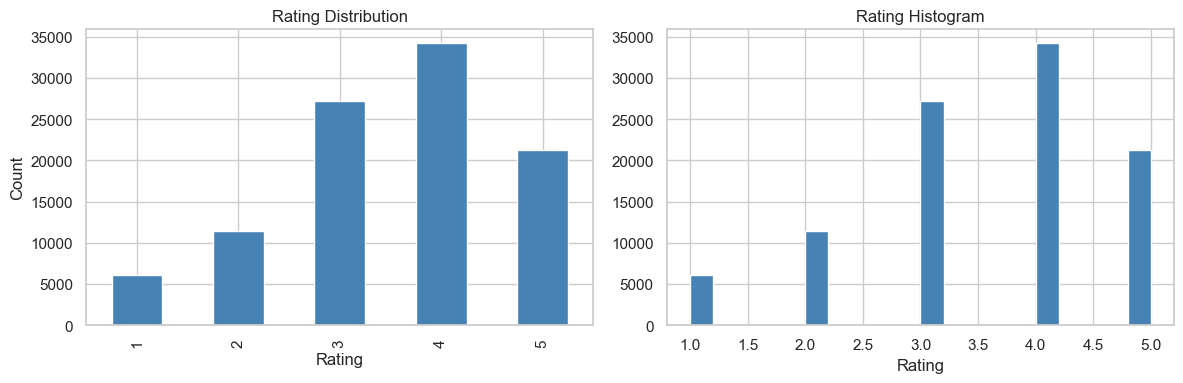

count    100000.000000
mean          3.529860
std           1.125674
min           1.000000
25%           3.000000
50%           4.000000
75%           4.000000
max           5.000000
Name: rating, dtype: float64


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['rating'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Rating Distribution')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')

axes[1].hist(df['rating'], bins=20, color='steelblue', edgecolor='white')
axes[1].set_title('Rating Histogram')
axes[1].set_xlabel('Rating')
plt.tight_layout()
plt.show()
print(df['rating'].describe())

## 3. User and item activity

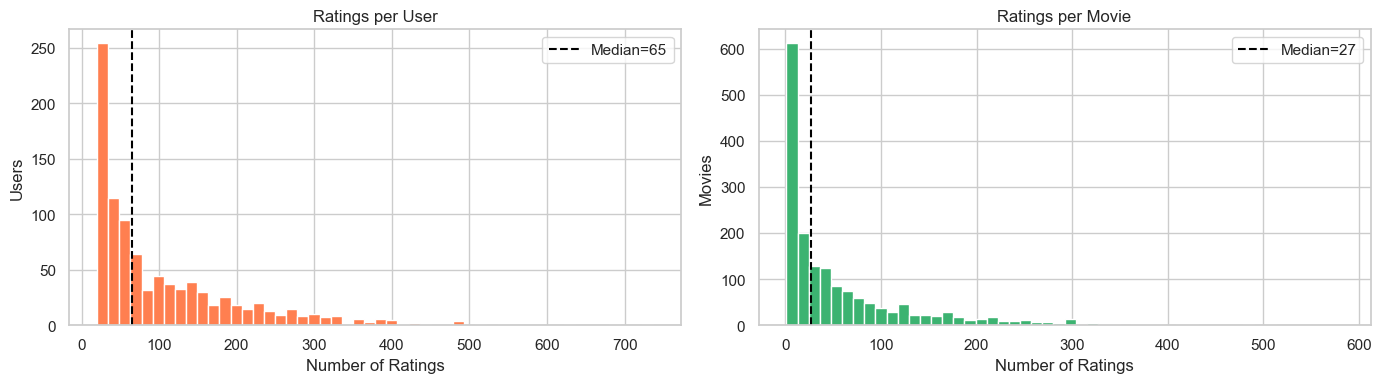

In [13]:
user_activity = df.groupby('user_id')['rating'].count()
item_activity = df.groupby('item_id')['rating'].count()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(user_activity, bins=50, color='coral', edgecolor='white')
axes[0].set_title('Ratings per User')
axes[0].set_xlabel('Number of Ratings')
axes[0].set_ylabel('Users')
axes[0].axvline(user_activity.median(), color='black', linestyle='--', label=f'Median={user_activity.median():.0f}')
axes[0].legend()

axes[1].hist(item_activity, bins=50, color='mediumseagreen', edgecolor='white')
axes[1].set_title('Ratings per Movie')
axes[1].set_xlabel('Number of Ratings')
axes[1].set_ylabel('Movies')
axes[1].axvline(item_activity.median(), color='black', linestyle='--', label=f'Median={item_activity.median():.0f}')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Matrix sparsity

In [14]:
n_users = df['user_id'].nunique()
n_items = df['item_id'].nunique()
n_possible = n_users * n_items
sparsity = 1 - len(df) / n_possible
print(f'Matrix size : {n_users} × {n_items} = {n_possible:,} cells')
print(f'Filled cells: {len(df):,}  ({100*(1-sparsity):.2f}%)')
print(f'Sparsity    : {100*sparsity:.2f}%')

Matrix size : 943 × 1682 = 1,586,126 cells
Filled cells: 100,000  (6.30%)
Sparsity    : 93.70%


## 5. Top-20 most-rated movies

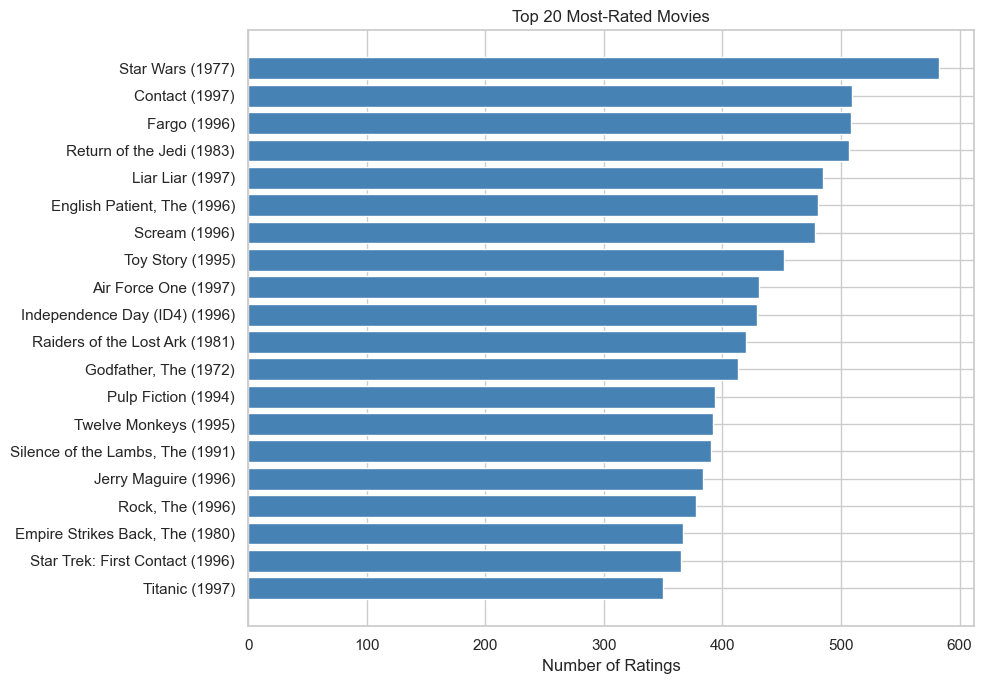

,title,n_ratings,avg_rating
0,Star Wars (1977),583,4.358491
1,Contact (1997),509,3.803536
2,Fargo (1996),508,4.155512
3,Return of the Jedi (1983),507,4.007890
4,Liar Liar (1997),485,3.156701
5,"English Patient, The (1996)",481,3.656965
6,Scream (1996),478,3.441423
7,Toy Story (1995),452,3.878319
8,Air Force One (1997),431,3.631090
9,Independence Day (ID4) (1996),429,3.438228


In [15]:
top20 = (
    df.groupby('item_id')['rating']
    .agg(['count', 'mean'])
    .rename(columns={'count': 'n_ratings', 'mean': 'avg_rating'})
    .merge(movies, on='item_id')
    .sort_values('n_ratings', ascending=False)
    .head(20)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(top20['title'].str[:40], top20['n_ratings'], color='steelblue')
ax.set_xlabel('Number of Ratings')
ax.set_title('Top 20 Most-Rated Movies')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

top20[['title', 'n_ratings', 'avg_rating']]

## 6. Create train/test splits

Run once; subsequent notebooks load from `data/processed/`.

In [8]:
train, test = split_ratings(df, test_size=0.2, random_state=42)
save_splits(train, test)
print(f'Train: {len(train):,} ratings | Test: {len(test):,} ratings')
print(f'Users in both: {len(set(train.user_id) & set(test.user_id))}')

Train: 79,619 ratings | Test: 20,381 ratings
Users in both: 943
